In [38]:
# Basic libraries 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
import pickle
import os
import sys

PROJECT_ROOT = os.path.abspath("..")
sys.path.insert(0, PROJECT_ROOT)

from src.local_config import *
from src.backtest import *
from src.bootstrap import *

In [39]:
# Load in data from previous notebook
df1_is = pd.read_csv(PROJECT_ROOT / "data/df1_is",
                     index_col=0, parse_dates=True)
df1_oos = pd.read_csv(PROJECT_ROOT / "data/df1_oos",
                      index_col=0, parse_dates=True)

df2_is = pd.read_csv(PROJECT_ROOT / "data/df2_is",
                     index_col=0, parse_dates=True)
df2_oos = pd.read_csv(PROJECT_ROOT / "data/df2_oos",
                      index_col=0, parse_dates=True)

In [40]:
# Load dictionaries from previous notebook
with open(PROJECT_ROOT / "data/dictionaries/is_results.pkl", "rb") as f:
    is_results = pickle.load(f)

with open(PROJECT_ROOT / "data/dictionaries/oos_results.pkl", "rb") as f:
    oos_results = pickle.load(f)

portfolio = pd.read_csv(PROJECT_ROOT / "data/portfolio")

In [41]:
# Load risk-free rate to calculate sharpe ratio
rf_is = pd.read_csv(PROJECT_ROOT / "data/rf_is",
                     index_col=0, parse_dates=True) 
rf_oos = pd.read_csv(PROJECT_ROOT / "data/rf_oos",
                     index_col=0, parse_dates=True)

## Construct IS and OOS portfolios

In [42]:
weights   = portfolio.set_index("pair")["weight"].to_dict()
obs_cov   = 1.0

is_portfolio_dict  = {}
oos_portfolio_dict = {}

for strategy_name, signals_dict in is_results.items():
    pair_rets = {}
    for (pair_name, R), df in signals_dict.items():
        if not np.isclose(float(R), obs_cov) or pair_name not in weights:
            continue
        df = compute_strategy_returns(df.copy())
        pair_rets[pair_name] = df["strategy_ret"] * weights[pair_name]
    if pair_rets:
        is_portfolio_dict[strategy_name] = pd.DataFrame(pair_rets).sum(axis=1)

for strategy_name, signals_dict in oos_results.items():
    pair_rets = {}
    for (pair_name, R), df in signals_dict.items():
        if not np.isclose(float(R), obs_cov) or pair_name not in weights:
            continue
        df = compute_strategy_returns(df.copy())
        pair_rets[pair_name] = df["strategy_ret"] * weights[pair_name]
    if pair_rets:
        oos_portfolio_dict[strategy_name] = pd.DataFrame(pair_rets).sum(axis=1)

print("IS  strategies:", list(is_portfolio_dict.keys()))
print("OOS strategies:", list(oos_portfolio_dict.keys()))

IS  strategies: ['entry_1.5_exit_0.0', 'entry_1.5_exit_0.5', 'entry_1.5_exit_1.0', 'entry_2.0_exit_0.0', 'entry_2.0_exit_0.5', 'entry_2.0_exit_1.0', 'entry_2.5_exit_0.0', 'entry_2.5_exit_0.5', 'entry_2.5_exit_1.0']
OOS strategies: ['entry_1.5_exit_0.0', 'entry_1.5_exit_0.5', 'entry_1.5_exit_1.0', 'entry_2.0_exit_0.0', 'entry_2.0_exit_0.5', 'entry_2.0_exit_1.0', 'entry_2.5_exit_0.0', 'entry_2.5_exit_0.5', 'entry_2.5_exit_1.0']


## In-Sample Backtest

In [43]:
is_portfolio_rows = []

for strategy_name, ret in is_portfolio_dict.items():
    ret = ret.dropna()
    mean_ret = ret.mean()
    std_ret  = ret.std()
    sharpe   = mean_ret / std_ret if std_ret != 0 else np.nan

    is_portfolio_rows.append({
        "strategy":    strategy_name,
        "entry_z":     float(strategy_name.split("_")[1]),
        "exit_z":      float(strategy_name.split("_")[3]),
        "sharpe":      sharpe,
        "total_return": ret.sum(),
    })

is_portfolio_signals = pd.DataFrame(is_portfolio_rows)

In [44]:
is_sharpe_pivot = is_portfolio_signals.pivot_table(
    index="entry_z", columns="exit_z", values="sharpe"
)

is_return_pivot = is_portfolio_signals.pivot_table(
    index="entry_z", columns="exit_z", values="total_return"
)

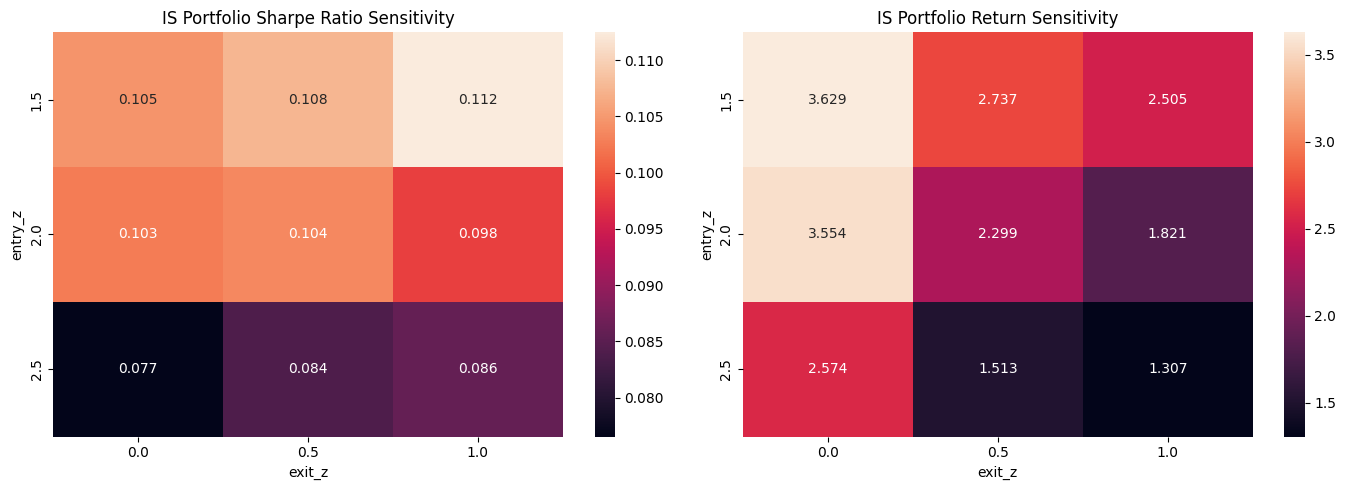

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    is_sharpe_pivot,
    annot=True,
    fmt=".3f",
    cmap="rocket",
    ax=axes[0]
)

axes[0].set_title("IS Portfolio Sharpe Ratio Sensitivity")
axes[0].set_xlabel("exit_z")
axes[0].set_ylabel("entry_z")

sns.heatmap(
    is_return_pivot,
    annot=True,
    fmt=".3f",
    cmap="rocket",
    ax=axes[1]
)

axes[1].set_title("IS Portfolio Return Sensitivity")
axes[1].set_xlabel("exit_z")
axes[1].set_ylabel("entry_z")

plt.tight_layout()
plt.show()

From our sensitivity analysis, we see it indicates that the strategy performs best using an entry threshold of 2.0 and an exit threshold of 0.0. This combination produces both the highest average Sharpe ratio and the highest average total return, suggesting that a moderate entry threshold provides the best balance between signal reliability and trade frequency. Lower entry thresholds may generate excessive trades based on weaker deviations, while higher thresholds may be too restrictive and reduce trading opportunities. The return heatmap also shows that exiting at 0.0 consistently outperforms exiting at 0.5 or 1.0, indicating that the strategy benefits from holding positions until the spread has fully reverted to its mean.

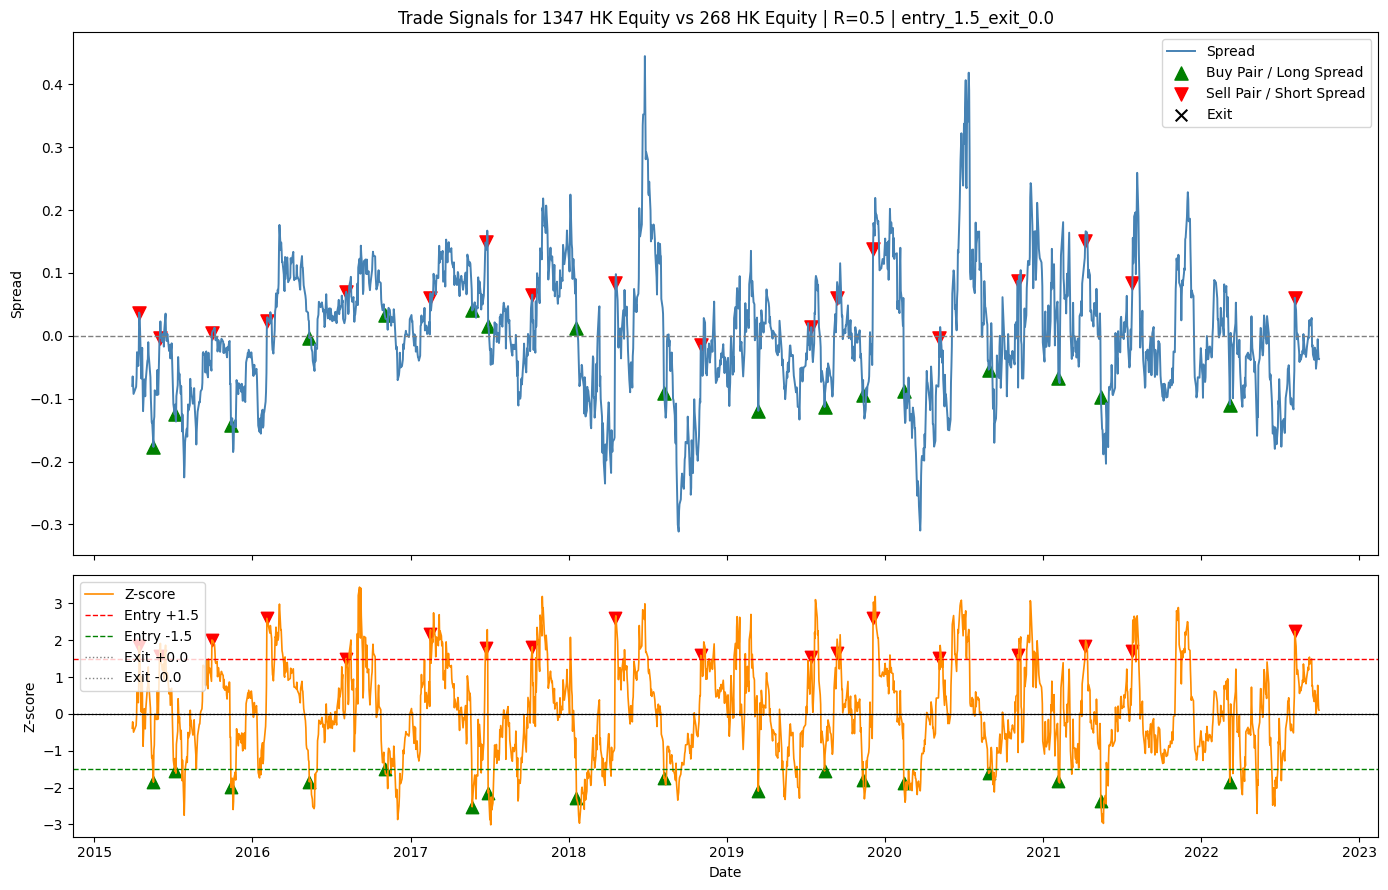

In [46]:
# An example of a pairs' trading signal 
strategy_name = sorted(is_results.keys())[0]
pair_name, obs_cov = next(iter(is_results[strategy_name].keys()))

plot_trade_signals(
    results_dict=is_results,
    strategy_name=strategy_name,
    pair_name=pair_name,
    obs_cov=obs_cov
)

### Performance metrics 

In [47]:
is_metrics  = performance_metrics(is_portfolio_dict["entry_1.5_exit_0.5"],  rf=rf_is, bootstrap_ci=True)

In [48]:
is_metrics

avg_return (%)                             0.1435
avg_excess_return (%)                      0.1523
annualised_sharpe        1.6959  [1.0552, 2.3756]
total_pnl                                  1093.6
hit_rate (%)                                54.18
max_drawdown (%)                           -23.12
num_obs                                      1850
dtype: object

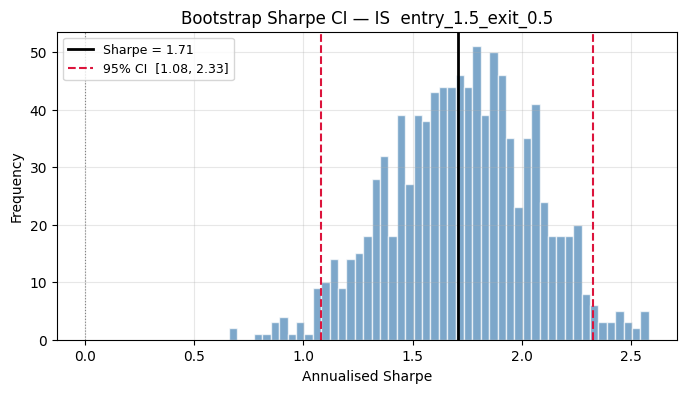

In [51]:
# Sharpe Ratio Bootstrapped Confidence Interval Plot
strategy_name = "entry_1.5_exit_0.5"

is_ci  = bootstrap_sharpe_ci(is_portfolio_dict[strategy_name],  seed=42)

plot_sharpe_ci(is_ci,  label=f"IS  {strategy_name}")
plt.show()

## OOS Backtest

### Performance Metrics

In [ ]:
oos_metrics = performance_metrics(oos_portfolio_dict["entry_1.5_exit_0.5"], rf=rf_oos, bootstrap_ci=True)

In [ ]:
oos_metrics

avg_return (%)                             0.1559
avg_excess_return (%)                      0.1435
annualised_sharpe        1.5842  [0.4435, 2.7388]
total_pnl                                  192.75
hit_rate (%)                                58.44
max_drawdown (%)                           -15.64
num_obs                                       738
dtype: object

In [ ]:
pd.DataFrame([is_metrics, oos_metrics], index=["In-Sample", "Out-of-Sample"])

,avg_return (%),avg_excess_return (%),annualised_sharpe,total_pnl,hit_rate (%),max_drawdown (%),num_obs
In-Sample,0.1435,0.1523,"1.6959 [1.0179, 2.3688]",1093.60,54.18,-23.12,1850
Out-of-Sample,0.1559,0.1435,"1.5842 [0.4435, 2.7388]",192.75,58.44,-15.64,738


### IS and OOS PnL Performance

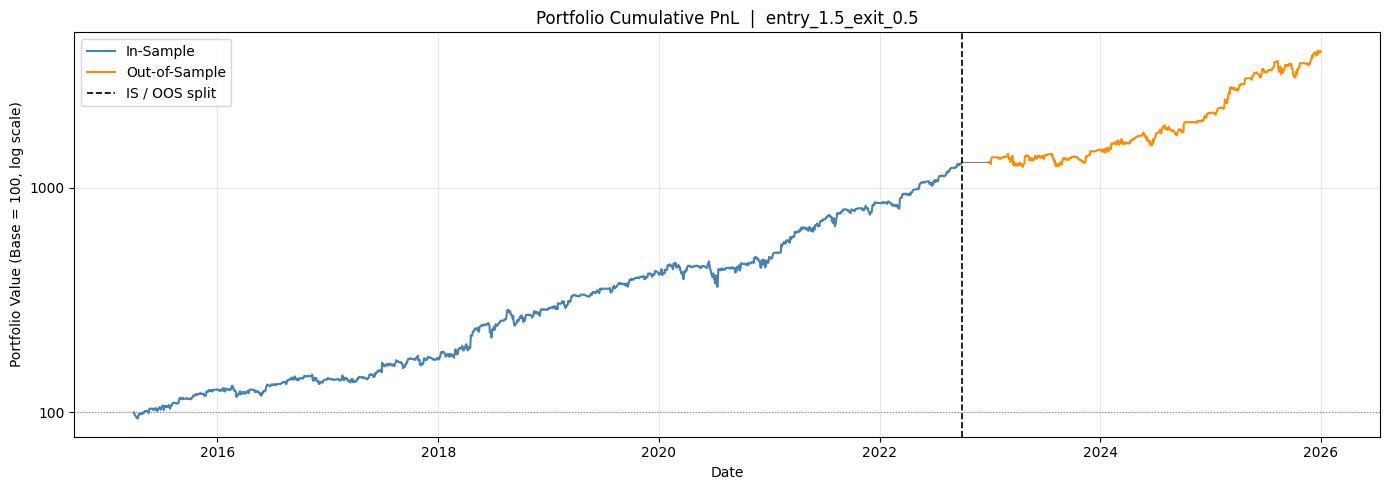

In [ ]:
save_dir = PROJECT_ROOT / "outputs/trading_signal"
label = "cumulative_pnl_base"
os.makedirs(save_dir, exist_ok=True)

strategy_name = "entry_1.5_exit_0.5"

is_ret  = is_portfolio_dict[strategy_name].fillna(0)
oos_ret = oos_portfolio_dict[strategy_name].fillna(0)

is_cum  = 100 * (1 + is_ret).cumprod()
oos_cum = is_cum.iloc[-1] * (1 + oos_ret).cumprod()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(is_cum.index,  is_cum,  color="steelblue", lw=1.5, label="In-Sample")
ax.plot(oos_cum.index, oos_cum, color="darkorange", lw=1.5, label="Out-of-Sample")
ax.plot([is_cum.index[-1], oos_cum.index[0]],
        [is_cum.iloc[-1],  oos_cum.iloc[0]], color="grey", lw=0.8)
ax.axvline(is_cum.index[-1], color="black", linestyle="--", lw=1.2, label="IS / OOS split")
ax.axhline(100, color="grey", linestyle=":", lw=0.8)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x)}"))
ax.yaxis.set_minor_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x)}"))
ax.yaxis.set_minor_locator(mticker.NullLocator()) 
ax.set_title(f"Portfolio Cumulative PnL  |  {strategy_name}")
ax.set_ylabel("Portfolio Value (Base = 100, log scale)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(save_dir / f"{label}_{strategy_name}_baseline_vs_refined.png", dpi=300, bbox_inches="tight")
plt.show()

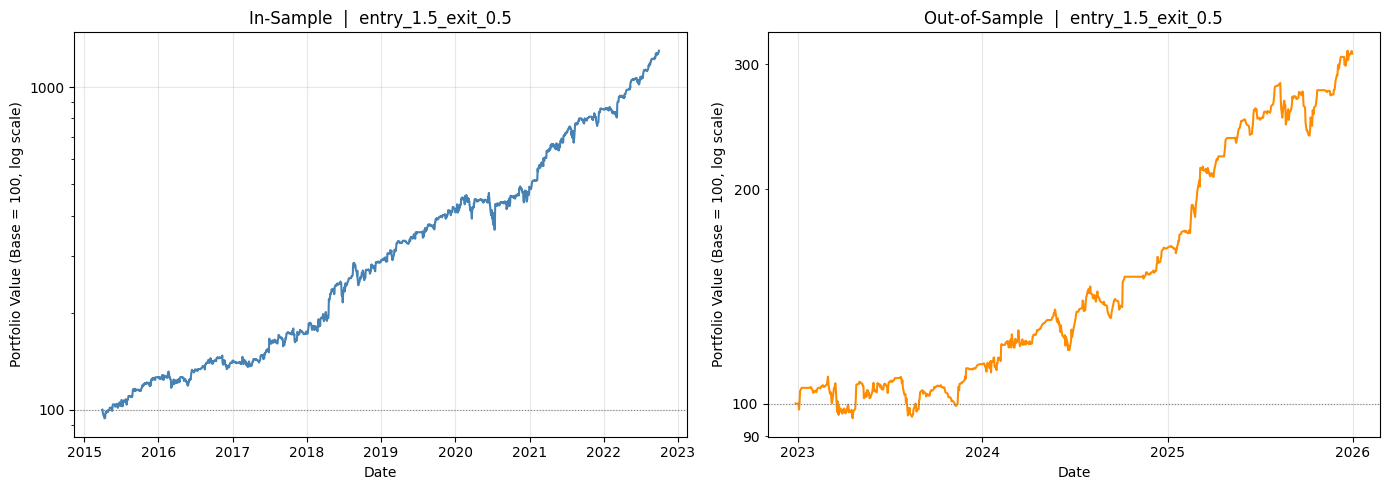

In [ ]:
is_ret  = is_portfolio_dict[strategy_name].fillna(0)
oos_ret = oos_portfolio_dict[strategy_name].fillna(0)

is_cum  = 100 * (1 + is_ret).cumprod()
oos_cum = 100 * (1 + oos_ret).cumprod()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

axes[0].plot(is_cum.index, is_cum, color="steelblue", lw=1.5)
axes[0].axhline(100, color="grey", linestyle=":", lw=0.8)
axes[0].set_title(f"In-Sample  |  {strategy_name}")
axes[0].set_ylabel("Portfolio Value (Base = 100, log scale)")
axes[0].set_xlabel("Date")
axes[0].set_yscale("log")
axes[0].yaxis.set_major_formatter(mticker.ScalarFormatter())
axes[0].yaxis.get_major_formatter().set_scientific(False)
axes[0].xaxis.set_major_locator(mdates.YearLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[0].grid(True, alpha=0.3)

axes[1].plot(oos_cum.index, oos_cum, color="darkorange", lw=1.5)
axes[1].axhline(100, color="grey", linestyle=":", lw=0.8)
axes[1].set_title(f"Out-of-Sample  |  {strategy_name}")
axes[1].set_ylabel("Portfolio Value (Base = 100, log scale)")
axes[1].set_xlabel("Date")
axes[1].set_yscale("log")
axes[1].yaxis.set_major_formatter(mticker.ScalarFormatter())
axes[1].yaxis.get_major_formatter().set_scientific(False)
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x)}"))
axes[1].yaxis.set_minor_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x)}"))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [52]:
# Save metrics to compare against refined trading signal performance
with open(PROJECT_ROOT / "data/dictionaries/is_metrics.pkl", "wb") as f:
    pickle.dump(is_metrics, f) 

with open(PROJECT_ROOT / "data/dictionaries/oos_metrics.pkl", "wb") as f:
    pickle.dump(oos_metrics, f) 

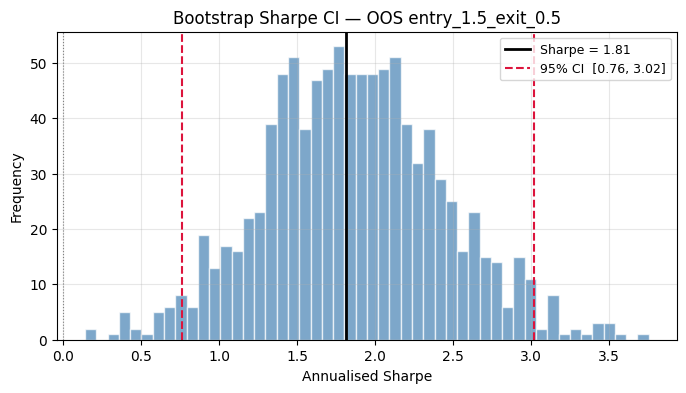

In [53]:
oos_ci = bootstrap_sharpe_ci(oos_portfolio_dict[strategy_name], seed=42)

plot_sharpe_ci(oos_ci, label=f"OOS {strategy_name}")
plt.show()